<a href="https://www.kaggle.com/code/vedikagupta0/catboost-lgbm-xgb-churn-prediction-0-912?scriptVersionId=305885898" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from catboost import CatBoostClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    accuracy_score
)
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
df_og = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
df2 = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')
tf = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

In [2]:
df_og.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [3]:
df2.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
id_col = ['id', 'customerID']

In [5]:
df_og.describe(include='object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,298738,309554,414362,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,460377


In [6]:
df2.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


##### no null values were observed

In [7]:
df2.shape

(7043, 21)

In [8]:
df_og.shape

(594194, 21)

In [9]:
df = pd.concat([df_og, df2], axis=0)

In [10]:
df.drop(columns=id_col, inplace=True)

In [11]:
df.shape

(601237, 20)

### mapped senior citizen to general binary format following the dataset format.

In [12]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0:'No', 1:'Yes'})
df_og['SeniorCitizen'] = df_og['SeniorCitizen'].map({0:'No', 1:'Yes'})
tf['SeniorCitizen'] = tf['SeniorCitizen'].map({0:'No', 1:'Yes'})

### since less cardinality exists, we can have a look at the unique values each feature possess.

In [13]:
for col in df.columns:
    print(f"{col} --> {df[col].unique()}")
    print()

gender --> ['Male' 'Female']

SeniorCitizen --> ['No' 'Yes']

Partner --> ['Yes' 'No']

Dependents --> ['Yes' 'No']

tenure --> [29 58  1 24 72 55 13 67 33 63  3 31 27 52 68 35 66 17 59 61 12 37 64 23
  9  8 15 18 19 51  5 71 60 62 45 69 40 53 54 34  2 70 39 41  4 22 46 28
 42 48 21 43 14 10 47  7 57 36 16 26 20 50 30 11 44 25 56  6 65 38 49 32
  0]

PhoneService --> ['Yes' 'No']

MultipleLines --> ['No' 'Yes' 'No phone service']

InternetService --> ['DSL' 'Fiber optic' 'No']

OnlineSecurity --> ['Yes' 'No' 'No internet service']

OnlineBackup --> ['No' 'Yes' 'No internet service']

DeviceProtection --> ['Yes' 'No' 'No internet service']

TechSupport --> ['Yes' 'No' 'No internet service']

StreamingTV --> ['No' 'Yes' 'No internet service']

StreamingMovies --> ['No' 'Yes' 'No internet service']

Contract --> ['One year' 'Two year' 'Month-to-month']

PaperlessBilling --> ['Yes' 'No']

PaymentMethod --> ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automa

In [14]:
df['tenure_counts'] = df['tenure'].map(df['tenure'].value_counts())
tf['tenure_counts'] = tf['tenure'].map(df['tenure'].value_counts())
df['is_fixed_contract_time'] = df['Contract'].apply(lambda x : True if 'year' in x else False)
df_og['is_fixed_contract_time'] = df_og['Contract'].apply(lambda x : True if 'year' in x else False)
tf['is_fixed_contract_time'] = tf['Contract'].apply(lambda x : True if 'year' in x else False)
df['is_automatic_payment'] = df['PaymentMethod'].apply(lambda x : True if 'automatic' in x else False)
df_og['is_automatic_payment'] = df_og['PaymentMethod'].apply(lambda x : True if 'automatic' in x else False)
tf['is_automatic_payment'] = tf['PaymentMethod'].apply(lambda x : True if 'automatic' in x else False)

In [15]:
df['TotalCharges'] = df['TotalCharges'].replace(' ',0).astype(float)
df['high_monthlycharges'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)
df['high_totalcharges'] = (df['TotalCharges'] > df['TotalCharges'].median()).astype(int)

tenure_75 = df['tenure'].quantile(0.75)
df['high_tenure'] = (df['tenure'] > tenure_75).astype(int)

def feature_streaming_internet_phone_all_true(df):
    return (
        (df['StreamingTV'] == 'Yes') &
        (df['StreamingMovies'] == 'Yes') &
        (df['InternetService'].isin(['DSL', 'Fiber optic'])) &
        (df['PhoneService'] == 'Yes')
    ).astype(int)


def feature_support_bundle_all_true(df):
    return (
        (df['DeviceProtection'] == 'Yes') &
        (df['OnlineBackup'] == 'Yes') &
        (df['OnlineSecurity'] == 'Yes') &
        (df['TechSupport'] == 'Yes')
    ).astype(int)

df['feat_streaming_internet_phone'] = feature_streaming_internet_phone_all_true(df)
df['feat_support_bundle'] = feature_support_bundle_all_true(df)

In [16]:
tf['TotalCharges'] = tf['TotalCharges'].replace('',0).astype(float)
tf['high_monthlycharges'] = (tf['MonthlyCharges'] > tf['MonthlyCharges'].median()).astype(int)
tf['high_totalcharges'] = (tf['TotalCharges'] > tf['TotalCharges'].median()).astype(int)

tenure_75 = tf['tenure'].quantile(0.75)
tf['high_tenure'] = (tf['tenure'] > tenure_75).astype(int)

tf['feat_streaming_internet_phone'] = feature_streaming_internet_phone_all_true(tf)
tf['feat_support_bundle'] = feature_support_bundle_all_true(tf)

### categorized columns into binary columns, trinary columns, numerical columns and other columns.

In [17]:
bin_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
trinary_cols = [
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]
combined_cols = bin_cols + trinary_cols
other_cols = ['InternetService', 'Contract', 'PaymentMethod']
num_cols =['tenure', 'TotalCharges', 'MonthlyCharges']

In [18]:
df[trinary_cols] = df[trinary_cols].replace({
    'No internet service':'Service Unavailable',
    'No phone service':'Service Unavailable'
})
tf[trinary_cols] = tf[trinary_cols].replace({
    'No internet service':'Service Unavailable',
    'No phone service':'Service Unavailable'
})

In [19]:
df[num_cols] = df[num_cols].replace(' ', 0).astype(float)
for col1 in num_cols:
    for col2 in num_cols:
        if col1!=col2:   
            df[f'{col1}_{col2}_ratio'] = df[col1]/df[col2]
            df_og[f'{col1}_{col2}_ratio'] = df_og[col1]/df_og[col2]
            tf[f'{col1}_{col2}_ratio'] = tf[col1]/tf[col2]

In [20]:
def all_same(df, cols):
    vals = df[cols].values
    return (vals == vals[:, [0]]).all(axis=1)

# binary
df['all_binary_same']    = all_same(df, bin_cols)
tf['all_binary_same']    = all_same(tf, bin_cols)
df_og['all_binary_same'] = all_same(df_og, bin_cols)

# trinary
df['all_trinary_same']    = all_same(df, trinary_cols)
tf['all_trinary_same']    = all_same(tf, trinary_cols)
df_og['all_trinary_same'] = all_same(df_og, trinary_cols)

# combined
df['all_same_services']    = all_same(df, combined_cols)
tf['all_same_services']    = all_same(tf, combined_cols)
df_og['all_same_services'] = all_same(df_og, combined_cols)

In [21]:
df['all_same_services'].value_counts()

all_same_services
False    601068
True        169
Name: count, dtype: int64

In [22]:
df = df.reset_index(drop=True)

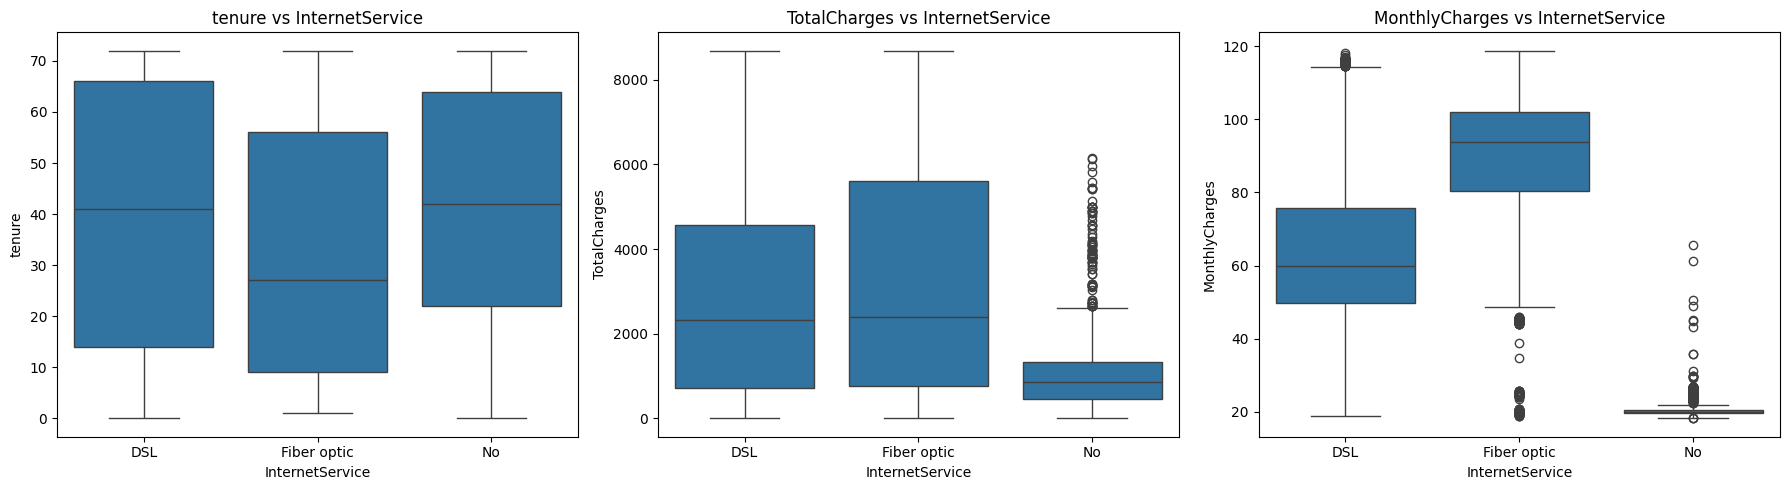

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(
        x="InternetService",
        y=col,
        data=df,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs InternetService")

plt.tight_layout()
plt.show()

In [24]:
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})
df_og['Churn'] = df_og['Churn'].map({'No':0, 'Yes':1})

In [25]:
cols = ['StreamingMovies', 'StreamingTV', 'TechSupport',
        'DeviceProtection', 'OnlineBackup', 'OnlineSecurity']

mask = (df[cols] == 'Service Unavailable').all(axis=1)
filtered_df = df[mask]
filtered_df.shape

(142253, 37)

In [26]:
no_int= 100 - ((df.shape[0] - 140727)/ df.shape[0])*100
print(f'{round(no_int,2)}% is having no service available in {cols}')

23.41% is having no service available in ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity']


In [27]:
dup = df.duplicated().sum()
print(f'{round(dup,3)} duplicate values exist in our df.')

22 duplicate values exist in our df.


#### removed duplicate values
#### added dominance of no internet service, same binary, trinary, same servicess, fixed contract time, automatic payment

In [28]:
df.drop_duplicates(inplace=True)

In [32]:
pattern_map = {
    "SeniorCitizen": 'Yes',
    "Dependents": 'Yes',
    "PhoneService": 'No',
    "PaperlessBilling": 'No',
    "all_trinary_same": 1,
    "all_binary_same": 1,
}
df['rarity_factor'] = sum(
    (df[col] == val).astype(int)
    for col, val in pattern_map.items()
)

df_og['rarity_factor'] = sum(
    (df_og[col] == val).astype(int)
    for col, val in pattern_map.items()
)

tf['rarity_factor'] = sum(
    (tf[col] == val).astype(int)
    for col, val in pattern_map.items()
)
n = len(pattern_map)

df['rarity_factor'] = 5 * df['rarity_factor'] / n
df_og['rarity_factor'] = 5 * df_og['rarity_factor'] / n
tf['rarity_factor'] = 5 * tf['rarity_factor'] / n

In [33]:
df['rarity_factor'].value_counts()

rarity_factor
0.833333    262345
0.000000    184801
1.666667    130764
2.500000     23003
3.333333       302
Name: count, dtype: int64

In [34]:
df_0 = df[df['Churn'] == 0]
df_1 = df[df['Churn'] == 1]

df_0_down = resample(
    df_0,
    replace=False,
    n_samples=135674,
    random_state=42
)

df = pd.concat([df_0_down, df_1])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"downsampled 'No Churn' to 1.5M!")
df.Churn.value_counts()

downsampled 'No Churn' to 1.5M!


Churn
1    135674
0    135674
Name: count, dtype: int64

In [35]:
cols=['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'is_fixed_contract_time', 'is_automatic_payment', 'high_monthlycharges',
       'high_totalcharges', 'high_tenure', 'feat_streaming_internet_phone',
       'feat_support_bundle', 'all_binary_same',
       'all_trinary_same', 'all_same_services', 'rarity_factor']

In [39]:
encodings = {}
label_encodings = {}
target = "Churn"

for col in cols:
    # target encoding
    target_map = df.groupby(col)[target].mean()
    encodings[col] = target_map

    # label encoding
    uniques = df[col].dropna().unique()
    label_map = {k: i for i, k in enumerate(uniques)}
    label_encodings[col] = label_map

    print(f"{col} target encoding:")
    print(target_map.to_dict())
    print(f"{col} label encoding:")
    print(label_map)
    print("-" * 40)

# apply both
for col in cols:
    df[col + "_le"]    = df[col].map(label_encodings[col])
    tf[col + "_le"]    = tf[col].map(label_encodings[col])
    df[col]    = df[col].map(encodings[col])
    tf[col]    = tf[col].map(encodings[col])


gender target encoding:
{0.49569170783975236: 0.49569170783975236, 0.5042276351528958: 0.5042276351528958}
gender label encoding:
{np.float64(0.5042276351528958): 0, np.float64(0.49569170783975236): 1}
----------------------------------------
SeniorCitizen target encoding:
{0.4461310756164818: 0.4461310756164818, 0.77583795732395: 0.77583795732395}
SeniorCitizen label encoding:
{np.float64(0.77583795732395): 0, np.float64(0.4461310756164818): 1}
----------------------------------------
Partner target encoding:
{0.3473502636943621: 0.3473502636943621, 0.6231514465492559: 0.6231514465492559}
Partner label encoding:
{np.float64(0.6231514465492559): 0, np.float64(0.3473502636943621): 1}
----------------------------------------
Dependents target encoding:
{0.2143735919599917: 0.2143735919599917, 0.585631415829585: 0.585631415829585}
Dependents label encoding:
{np.float64(0.585631415829585): 0, np.float64(0.2143735919599917): 1}
----------------------------------------
PhoneService target en

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scale_cols = ['tenure',
       'MonthlyCharges', 'TotalCharges', 'tenure_TotalCharges_ratio',
       'tenure_MonthlyCharges_ratio', 'TotalCharges_tenure_ratio',
       'TotalCharges_MonthlyCharges_ratio', 'MonthlyCharges_tenure_ratio',
       'MonthlyCharges_TotalCharges_ratio','tenure_counts','gender_le',
       'SeniorCitizen_le', 'Partner_le', 'Dependents_le', 'PhoneService_le',
       'MultipleLines_le', 'InternetService_le', 'OnlineSecurity_le',
       'OnlineBackup_le', 'DeviceProtection_le', 'TechSupport_le',
       'StreamingTV_le', 'StreamingMovies_le', 'Contract_le',
       'PaperlessBilling_le', 'PaymentMethod_le', 'all_binary_same_le',
       'all_trinary_same_le', 'all_same_services_le',
       'is_fixed_contract_time_le', 'is_automatic_payment_le']


df[scale_cols] = df[scale_cols].apply(pd.to_numeric, errors='coerce')
tf[scale_cols] = tf[scale_cols].apply(pd.to_numeric, errors='coerce')

In [43]:
df.Churn.value_counts()

Churn
1    135674
0    135674
Name: count, dtype: int64

In [51]:
target_col = 'Churn'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)
X_train = X_train.clip(-1e6, 1e6)
X_test  = X_test.clip(-1e6, 1e6)


print(X_train.isnull().sum().sum(), X_test.isnull().sum().sum())
X_train.fillna(-1, inplace=True)
print(X_train.isnull().sum().sum(), X_test.isnull().sum().sum())

6 0
0 0


In [67]:
import warnings
warnings.filterwarnings('ignore')

## RF

Best trees: 46
    threshold  train_acc  test_acc  train_f1   test_f1  train_roc  test_roc
0        0.00   0.500002  0.499988  0.666669  0.666656   0.915332    0.9145
1        0.05   0.706909  0.708351  0.772435  0.773043   0.915332    0.9145
2        0.10   0.746754  0.746309  0.796237  0.795678   0.915332    0.9145
3        0.15   0.778356  0.777805  0.815722  0.815112   0.915332    0.9145
4        0.20   0.794606  0.793996  0.825849  0.825178   0.915332    0.9145
5        0.25   0.808472  0.807557  0.834447  0.833479   0.915332    0.9145
6        0.30   0.820100  0.819227  0.841121  0.840231   0.915332    0.9145
7        0.35   0.827731  0.827752  0.844922  0.844797   0.915332    0.9145
8        0.40   0.833051  0.832224  0.846909  0.846072   0.915332    0.9145
9        0.45   0.837061  0.835737  0.847484  0.846150   0.915332    0.9145
10       0.50   0.838813  0.838931  0.845313  0.845173   0.915332    0.9145
11       0.55   0.837213  0.837162  0.839859  0.839624   0.915332    0.91

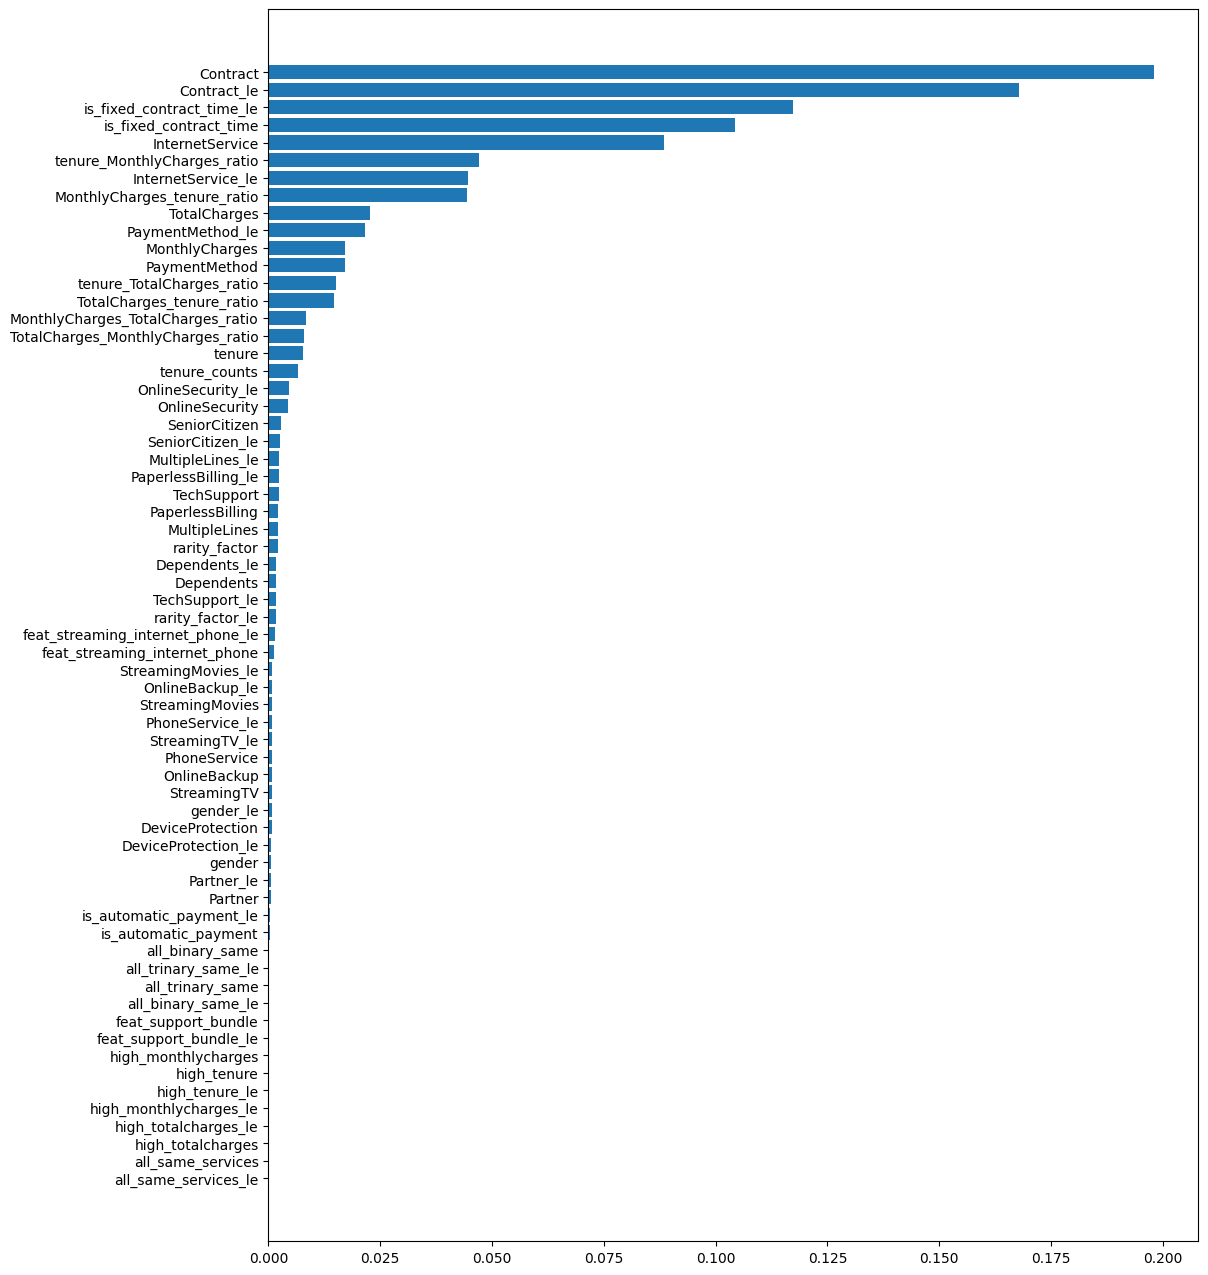

In [68]:
# incremental training
rf = RandomForestClassifier(
    n_estimators=1,
    max_depth=9,
    warm_start=True,
    oob_score=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

best_oob = 0
no_improve = 0
patience = 10
max_trees = 300

for i in range(1, max_trees + 1):
    rf.n_estimators = i
    rf.fit(X_train, y_train)

    if rf.oob_score_ > best_oob + 1e-4:
        best_oob = rf.oob_score_
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        break

print("Best trees:", rf.n_estimators)

# probabilities
train_probs = rf.predict_proba(X_train)[:, 1]
test_probs  = rf.predict_proba(X_test)[:, 1]

# compute ROC once
train_roc = roc_auc_score(y_train, train_probs)
test_roc  = roc_auc_score(y_test, test_probs)

thresholds = np.arange(0.0, 1.01, 0.05)
rows = []

for t in thresholds:
    train_preds = (train_probs >= t).astype(int)
    test_preds  = (test_probs  >= t).astype(int)

    row = {
        "threshold": round(t, 2),
        "train_acc": accuracy_score(y_train, train_preds),
        "test_acc": accuracy_score(y_test, test_preds),
        "train_f1": f1_score(y_train, train_preds),
        "test_f1": f1_score(y_test, test_preds),
        "train_roc": train_roc,
        "test_roc": test_roc
    }

    rows.append(row)

thresh_df = pd.DataFrame(rows)
print(thresh_df)

importances = gb.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(12, 16))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.show()

In [72]:
submission_ensemble = pd.DataFrame({
    "id": tf_id,
    "Churn": rf.predict_proba(tf)[:, 1] 
})

submission_ensemble.to_csv("rf_churn_predictions.csv", index=False)
print('Converted submission to csv format!') # 0.90897

Converted submission to csv format!


## GB

Best n_estimators: 143
    threshold  train_acc  test_acc  train_f1   test_f1  train_roc  test_roc
0        0.00   0.500002  0.499988  0.666669  0.666656   0.933714  0.917355
1        0.05   0.716599  0.715574  0.778483  0.777310   0.933714  0.917355
2        0.10   0.768324  0.762941  0.810524  0.806007   0.933714  0.917355
3        0.15   0.798756  0.790040  0.830288  0.822932   0.933714  0.917355
4        0.20   0.815999  0.803995  0.841650  0.831417   0.933714  0.917355
5        0.25   0.828993  0.815419  0.850194  0.838322   0.933714  0.917355
6        0.30   0.840656  0.824018  0.857931  0.843353   0.933714  0.917355
7        0.35   0.849349  0.830578  0.863215  0.846332   0.933714  0.917355
8        0.40   0.855020  0.835737  0.865888  0.848066   0.933714  0.917355
9        0.45   0.858718  0.840159  0.866756  0.849070   0.933714  0.917355
10       0.50   0.860157  0.840528  0.865431  0.846371   0.933714  0.917355
11       0.55   0.859178  0.839447  0.861316  0.841587   0.933714

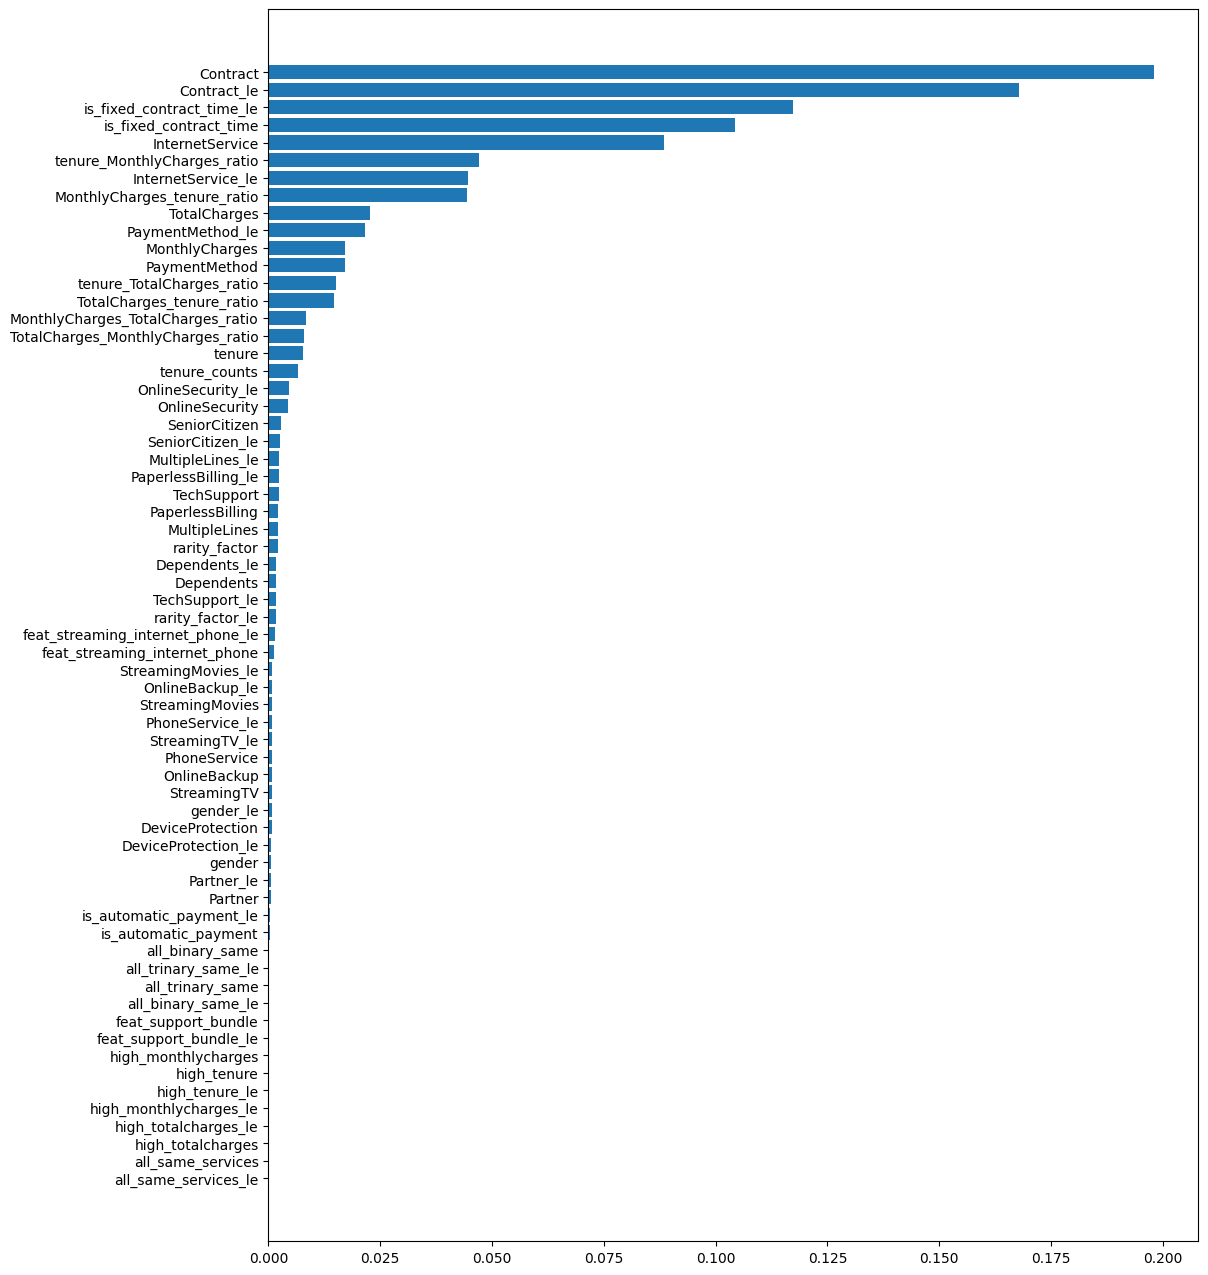

In [56]:
# model with early stopping
gb = GradientBoostingClassifier(
    n_estimators=1000,          
    learning_rate=0.05,
    max_depth=9,
    validation_fraction=0.1,    
    n_iter_no_change=20,       
    tol=1e-4,
    random_state=42
)

gb.fit(X_train, y_train)

# actual trees used
print("Best n_estimators:", gb.n_estimators_)

# probabilities
train_probs = gb.predict_proba(X_train)[:, 1]
test_probs  = gb.predict_proba(X_test)[:, 1]

# compute ROC once
train_roc = roc_auc_score(y_train, train_probs)
test_roc  = roc_auc_score(y_test, test_probs)

thresholds = np.arange(0.0, 1.01, 0.05)
rows = []

for t in thresholds:
    train_preds = (train_probs >= t).astype(int)
    test_preds  = (test_probs  >= t).astype(int)

    row = {
        "threshold": round(t, 2),
        "train_acc": accuracy_score(y_train, train_preds),
        "test_acc": accuracy_score(y_test, test_preds),
        "train_f1": f1_score(y_train, train_preds),
        "test_f1": f1_score(y_test, test_preds),
        "train_roc": train_roc,
        "test_roc": test_roc
    }

    rows.append(row)

thresh_df = pd.DataFrame(rows)
print(thresh_df)


importances = gb.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(12, 16))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.show()

In [61]:
tf_id = tf.pop('id')

In [65]:
tf = tf[X_train.columns]
submission_ensemble = pd.DataFrame({
    "id": tf_id,
    "Churn": gb.predict_proba(tf)[:, 1] 
})

submission_ensemble.to_csv("gb_churn_predictions_updated_FE1.csv", index=False)
print('Converted submission to csv format!') # 91186

Converted submission to csv format!


## XGB

In [78]:
# pip install -U xgboost

    threshold  train_acc  test_acc  train_f1   test_f1  train_roc  test_roc
0        0.00   0.500002  0.499988  0.666669  0.666656   0.933936  0.917871
1        0.05   0.721407  0.719529  0.781628  0.779699   0.933936  0.917871
2        0.10   0.770279  0.762401  0.812068  0.805604   0.933936  0.917871
3        0.15   0.798227  0.788591  0.830230  0.822075   0.933936  0.917871
4        0.20   0.815973  0.804240  0.841937  0.831735   0.933936  0.917871
5        0.25   0.829452  0.815738  0.850800  0.838807   0.933936  0.917871
6        0.30   0.840079  0.824583  0.857582  0.843805   0.933936  0.917871
7        0.35   0.848195  0.831757  0.862332  0.847286   0.933936  0.917871
8        0.40   0.853719  0.836646  0.864840  0.848965   0.933936  0.917871
9        0.45   0.857196  0.840847  0.865412  0.849726   0.933936  0.917871
10       0.50   0.858133  0.841289  0.863478  0.847050   0.933936  0.917871
11       0.55   0.856624  0.838833  0.858719  0.840862   0.933936  0.917871
12       0.6

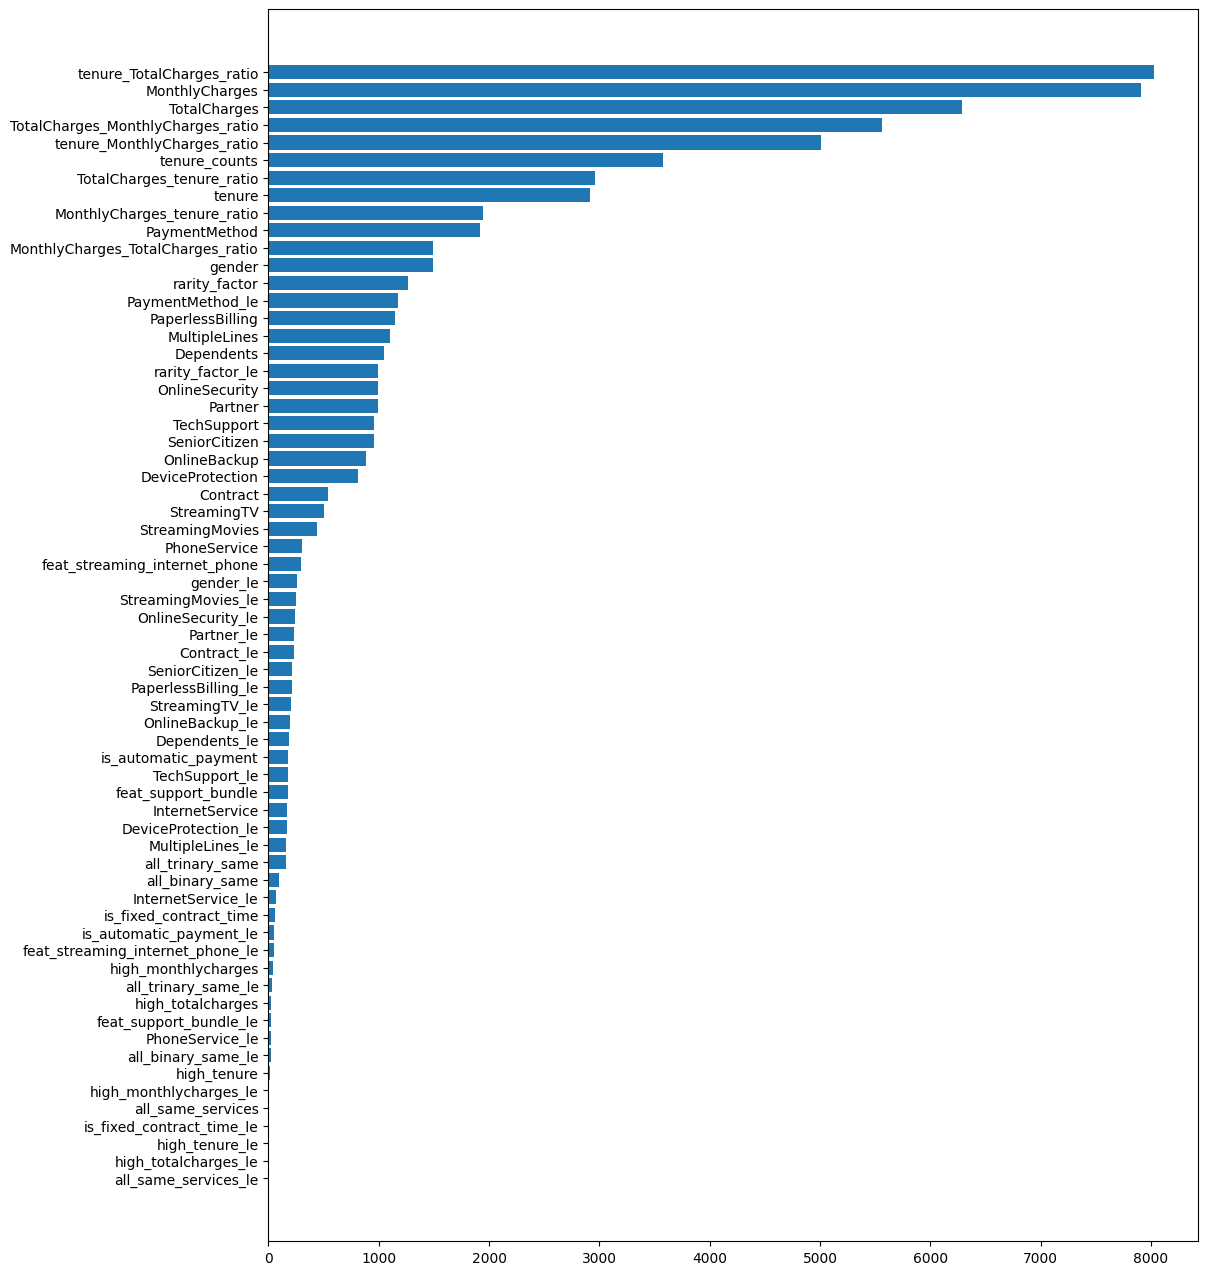

In [95]:
# convert to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "max_depth": 9,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtest, "eval")],
    early_stopping_rounds=20,
    verbose_eval=False
)

# probabilities
train_probs = model.predict(dtrain)
test_probs  = model.predict(dtest)

train_roc = roc_auc_score(y_train, train_probs)
test_roc  = roc_auc_score(y_test, test_probs)

thresholds = np.arange(0.0, 1.01, 0.05)
rows = []

for t in thresholds:
    train_preds = (train_probs >= t).astype(int)
    test_preds  = (test_probs  >= t).astype(int)

    rows.append({
        "threshold": round(t, 2),
        "train_acc": accuracy_score(y_train, train_preds),
        "test_acc": accuracy_score(y_test, test_preds),
        "train_f1": f1_score(y_train, train_preds),
        "test_f1": f1_score(y_test, test_preds),
        "train_roc": train_roc,
        "test_roc": test_roc
    })

thresh_df = pd.DataFrame(rows)
print(thresh_df)


# get importance from booster
importance_dict = model.get_score(importance_type='weight')

# convert to dataframe
feat_imp = pd.DataFrame({
    "feature": list(importance_dict.keys()),
    "importance": list(importance_dict.values())
})
# align with all features (fill missing with 0)
feat_imp = feat_imp.set_index("feature").reindex(X_train.columns, fill_value=0).reset_index()

# sort
feat_imp = feat_imp.sort_values(by="importance", ascending=False)

# plot
plt.figure(figsize=(12, 16))
plt.barh(feat_imp["index"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.show()

In [86]:
dtest_final = xgb.DMatrix(tf)

preds = model.predict(dtest_final)

submission_ensemble = pd.DataFrame({
    "id": tf_id,
    "Churn": preds
})

submission_ensemble.to_csv("xgb_churn_predictions_updated_FE1.csv", index=False)
print('Converted submission to csv format!') # 91200

Converted submission to csv format!


## CatBoost

Best iteration: 754
    threshold  train_acc  test_acc  train_f1   test_f1  train_roc  test_roc
0        0.00   0.500002  0.499988  0.666669  0.666656   0.924385  0.918068
1        0.05   0.714930  0.716335  0.777301  0.777791   0.924385  0.918068
2        0.10   0.760840  0.759305  0.805247  0.803750   0.924385  0.918068
3        0.15   0.789499  0.788345  0.823428  0.822081   0.924385  0.918068
4        0.20   0.807058  0.803135  0.834616  0.831145   0.924385  0.918068
5        0.25   0.820100  0.815468  0.842905  0.838754   0.924385  0.918068
6        0.30   0.830740  0.824951  0.849465  0.844368   0.924385  0.918068
7        0.35   0.839099  0.831855  0.854152  0.847613   0.924385  0.918068
8        0.40   0.844891  0.836671  0.856637  0.849135   0.924385  0.918068
9        0.45   0.848512  0.840208  0.857213  0.849284   0.924385  0.918068
10       0.50   0.849882  0.840945  0.855547  0.846675   0.924385  0.918068
11       0.55   0.848551  0.839471  0.850752  0.841592   0.924385  0

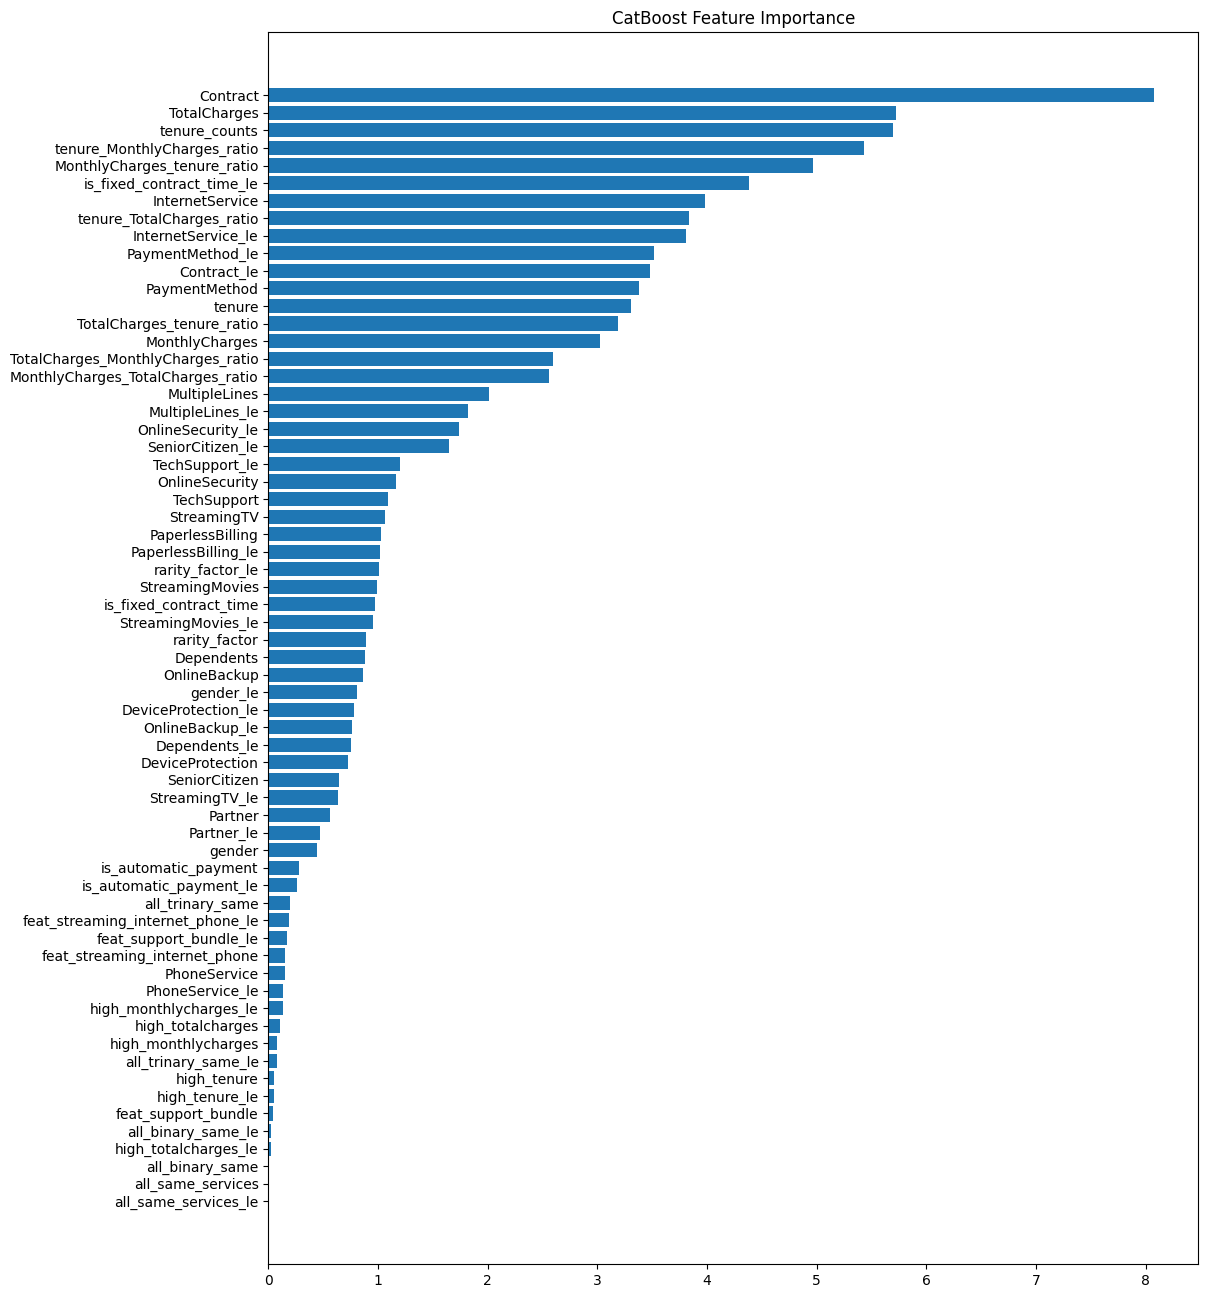

In [92]:
# model with early stopping
cat = CatBoostClassifier(
    iterations=2000,              
    learning_rate=0.03,
    depth=9,
    eval_metric="AUC",
    early_stopping_rounds=50,     
    use_best_model=True,
    verbose=0,
    random_state=42
)

cat.fit(
    X_train, y_train,
    eval_set=(X_test, y_test)
)

print("Best iteration:", cat.get_best_iteration())

# probabilities
train_probs = cat.predict_proba(X_train)[:, 1]
test_probs  = cat.predict_proba(X_test)[:, 1]

# compute ROC once
train_roc = roc_auc_score(y_train, train_probs)
test_roc  = roc_auc_score(y_test, test_probs)

thresholds = np.arange(0.0, 1.01, 0.05)
rows = []

for t in thresholds:
    train_preds = (train_probs >= t).astype(int)
    test_preds  = (test_probs  >= t).astype(int)

    rows.append({
        "threshold": round(t, 2),
        "train_acc": accuracy_score(y_train, train_preds),
        "test_acc": accuracy_score(y_test, test_preds),
        "train_f1": f1_score(y_train, train_preds),
        "test_f1": f1_score(y_test, test_preds),
        "train_roc": train_roc,
        "test_roc": test_roc
    })

thresh_df = pd.DataFrame(rows)
print(thresh_df)

cat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": cat.get_feature_importance()
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(12, 16))
plt.barh(cat_imp["feature"], cat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("CatBoost Feature Importance")
plt.show()

In [89]:
submission_ensemble = pd.DataFrame({
    "id": tf_id,
    "Churn": cat.predict_proba(tf)[:, 1] 
})

submission_ensemble.to_csv("cat_churn_predictions_updated_FE1.csv", index=False)
print('Converted submission to csv format!') # 91237

Converted submission to csv format!


## LGBM

[LightGBM] [Info] Number of positive: 115323, number of negative: 115322
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.059357 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2350
[LightGBM] [Info] Number of data points in the train set: 230645, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500002 -> initscore=0.000009
[LightGBM] [Info] Start training from score 0.000009
Best iteration: 527
    threshold  train_acc  test_acc  train_f1   test_f1  train_roc  test_roc
0        0.00   0.500002  0.499988  0.666669  0.666656   0.922859  0.918205
1        0.05   0.713035  0.713068  0.776325  0.775899   0.922859  0.918205
2        0.10   0.761335  0.760976  0.805620  0.804925   0.922859  0.918205
3        0.15   0.788563  0.787780  0.822688  0.821566   0.922859  0.918205
4        0.20   0.805528  0.802717  0.833

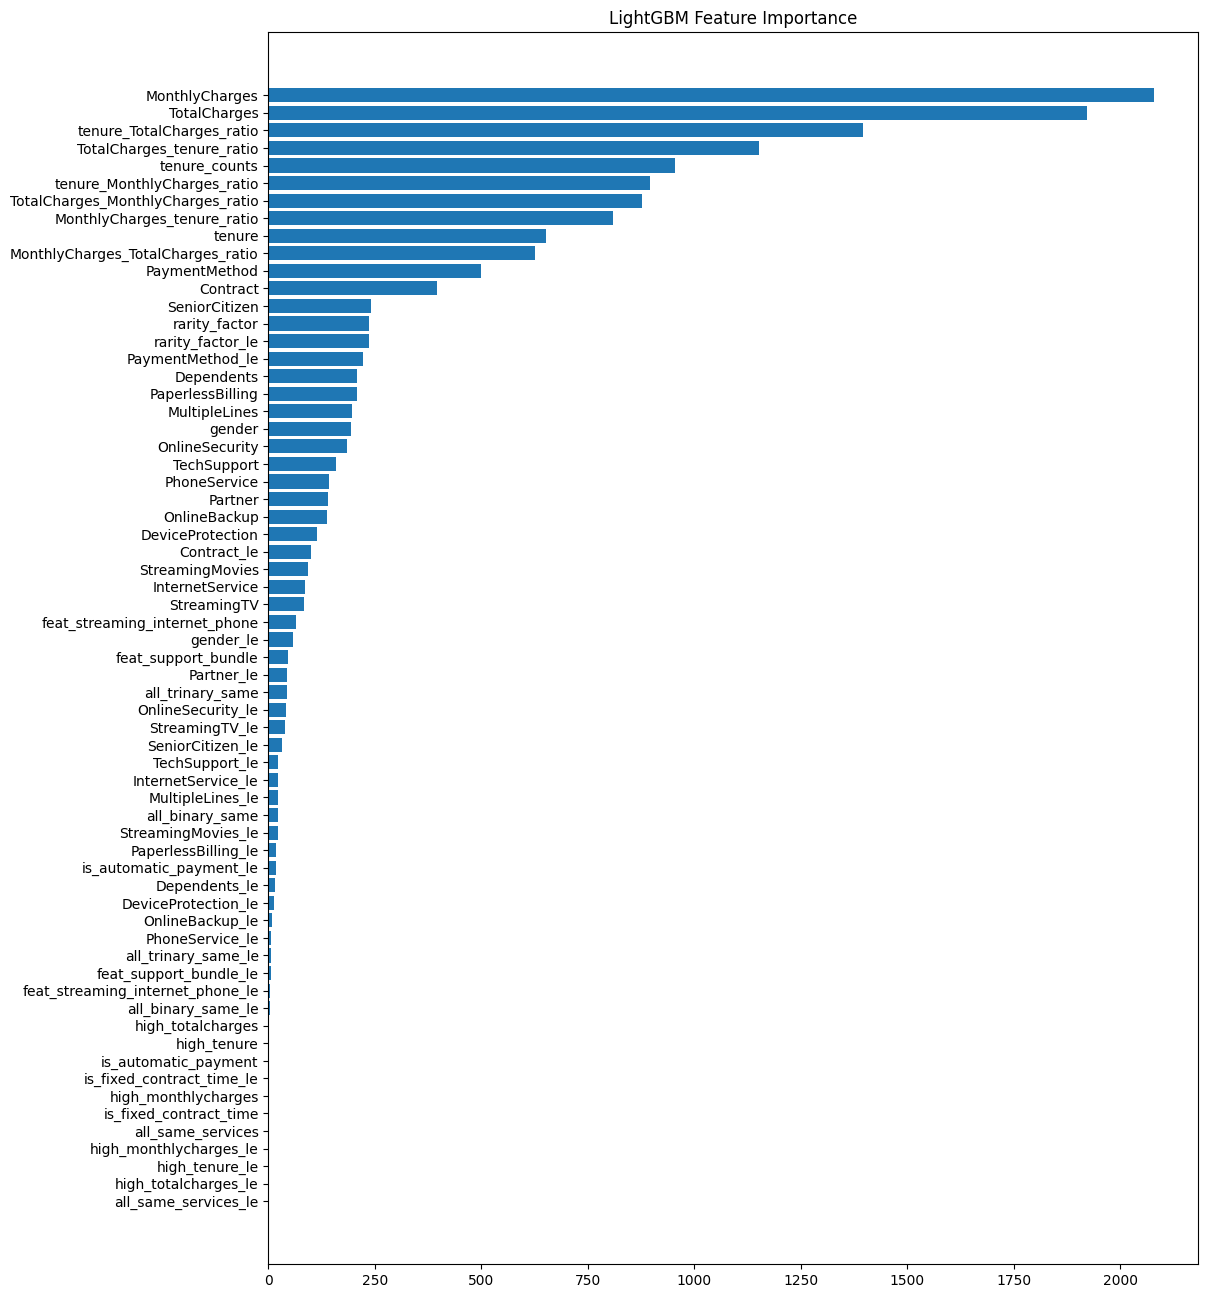

In [93]:
# model with early stopping
lgbm = lgb.LGBMClassifier(
    n_estimators=2000,          # large upper bound
    learning_rate=0.05,
    max_depth=9,
    random_state=42
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print("Best iteration:", lgbm.best_iteration_)

# probabilities
train_probs = lgbm.predict_proba(X_train)[:, 1]
test_probs  = lgbm.predict_proba(X_test)[:, 1]

# compute ROC once
train_roc = roc_auc_score(y_train, train_probs)
test_roc  = roc_auc_score(y_test, test_probs)

# thresholds
thresholds = np.arange(0.0, 1.01, 0.05)
rows = []

for t in thresholds:
    train_preds = (train_probs >= t).astype(int)
    test_preds  = (test_probs  >= t).astype(int)

    rows.append({
        "threshold": round(t, 2),
        "train_acc": accuracy_score(y_train, train_preds),
        "test_acc": accuracy_score(y_test, test_preds),
        "train_f1": f1_score(y_train, train_preds),
        "test_f1": f1_score(y_test, test_preds),
        "train_roc": train_roc,
        "test_roc": test_roc
    })

thresh_df = pd.DataFrame(rows)
print(thresh_df)

lgb_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(12, 16))
plt.barh(lgb_imp["feature"], lgb_imp["importance"])
plt.gca().invert_yaxis()
plt.title("LightGBM Feature Importance")
plt.show()

In [91]:
submission_ensemble = pd.DataFrame({
    "id": tf_id,
    "Churn": lgbm.predict_proba(tf)[:, 1] 
})

submission_ensemble.to_csv("lgbm_churn_predictions_updated_FE1.csv", index=False)
print('Converted submission to csv format!') # 91249

Converted submission to csv format!


### eliminated rf and gb after reviewing how the other 3 are performing, I will boost the 3 models xgb, lgbm and cat.